# Работа с целевой переменной

## Отбор признаков по важности

# Каримова Идэль ИД24-3

## Классная работа

In [1]:
from sklearn.datasets import fetch_openml

In [2]:
df = fetch_openml("mtp", version=1)

df.data.head()

,oz1,oz2,oz3,oz4,oz5,oz6,oz7,oz8,oz9,oz10,...,oz193,oz194,oz195,oz196,oz197,oz198,oz199,oz200,oz201,oz202
0,0.076923,0.325000,0.035088,0.200000,0.162112,0.194562,0.003900,0.060606,0.166667,0.045872,...,0.013874,0.071602,0.056880,0.179132,0.505899,0.039213,0.091327,0.321109,0.127564,0.188387
1,0.230769,0.375000,0.042105,0.333333,0.464191,0.622795,0.077623,0.373737,0.305556,0.192661,...,0.006342,0.186056,0.287438,0.384236,0.683820,0.326584,0.117990,0.456665,0.475618,0.401935
2,0.269231,0.437500,0.052632,0.333333,0.506556,0.531840,0.054374,0.212121,0.333333,0.229358,...,0.005018,0.179544,0.117431,0.384550,0.499219,0.204885,0.155967,0.360441,0.497968,0.407742
3,0.153846,0.357143,0.039474,0.266667,0.352880,0.394131,0.019654,0.171717,0.277778,0.091743,...,0.004801,0.091771,0.145349,0.243064,0.630533,0.023469,0.124430,0.336023,0.134458,0.252258
4,0.153846,0.357143,0.039474,0.266667,0.350523,0.320546,0.013154,0.101010,0.166667,0.110092,...,0.011166,0.130755,0.067583,0.250832,0.516053,0.111398,0.125693,0.332113,0.295913,0.253548


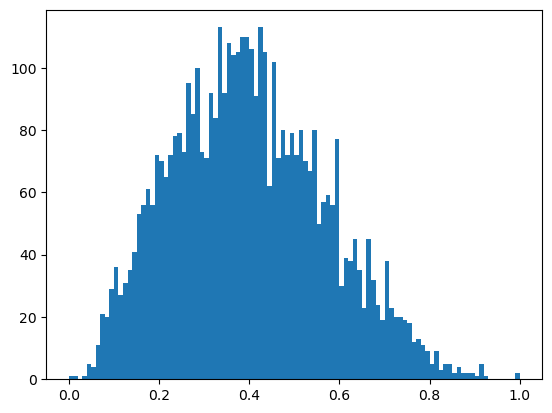

In [3]:
import matplotlib.pyplot as plt

plt.hist(df.target, 100)
_ = plt.plot()

Построение базовой (baseline) модели

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.data, df.target, test_size=0.25, random_state=42)

In [5]:
from sklearn.linear_model import LinearRegression

baseline = LinearRegression()
baseline.fit(X_train, y_train)
bl_score = baseline.score(X_test, y_test)
bl_score

-1.6511340769823937

In [6]:
y_pred = baseline.predict(X_test)

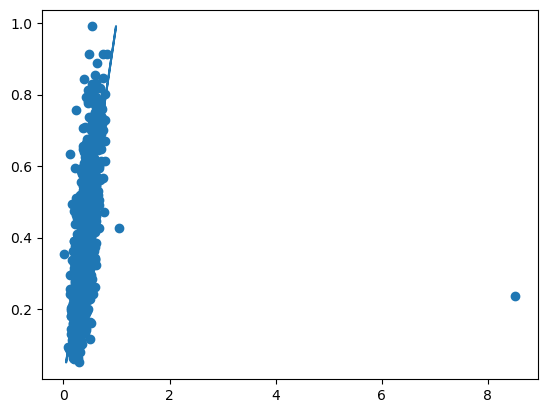

In [7]:
plt.plot(y_test, y_test)
plt.scatter(y_pred, y_test)

__Определение относительной важности признаков__

In [8]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=15).fit(X_train, y_train)

Text(0.5, 0, 'Feature Importance')

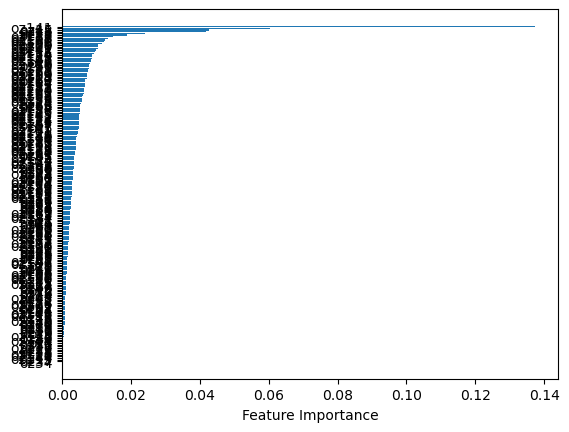

In [9]:
sort = rf.feature_importances_.argsort()
plt.barh(df.data.columns[sort], rf.feature_importances_[sort])
plt.xlabel("Feature Importance")

In [10]:
rf.feature_importances_[sort][-10:]

array([0.01223376, 0.01235375, 0.01317741, 0.01483191, 0.01885356,
       0.02397456, 0.04173192, 0.04276284, 0.0604574 , 0.13721206])

In [11]:
df.data.columns[sort][-10:]

Index(['oz198', 'oz180', 'oz197', 'oz158', 'oz137', 'oz18', 'oz35', 'oz48',
       'oz15', 'oz141'],
      dtype='object')

In [12]:
trimmed = df.data[df.data.columns[sort][-20:]]
trimmed.head()

,oz161,oz153,oz179,oz154,oz155,oz112,oz47,oz201,oz20,oz109,oz198,oz180,oz197,oz158,oz137,oz18,oz35,oz48,oz15,oz141
0,0.382067,0.052296,0.025609,0.030205,0.752291,0.000000,0.102941,0.127564,0.000000,0.076923,0.039213,0.002655,0.505899,0.800120,0.000000,0.0625,0.0,0.312855,0.000000,0.041308
1,0.383458,0.060922,0.024601,0.016908,0.745984,0.222222,0.389706,0.475618,0.242424,0.153846,0.326584,0.002581,0.683820,0.791224,0.278945,0.0625,0.4,0.297041,0.282828,0.212274
2,0.382596,0.072628,0.025104,0.006922,0.753298,0.000000,0.257353,0.497968,0.388889,0.076923,0.204885,0.002722,0.499219,0.798276,0.000000,0.1250,0.0,0.288557,0.388889,0.063643
3,0.382776,0.054593,0.025280,0.001240,0.767469,0.000000,0.198529,0.134458,0.095238,0.076923,0.023469,0.002473,0.630533,0.800965,0.039437,0.0000,0.1,0.310692,0.111111,0.031193
4,0.383539,0.045400,0.024934,0.011829,0.741548,0.000000,0.154412,0.295913,0.260870,0.076923,0.111398,0.002810,0.516053,0.802893,0.000000,0.0625,0.0,0.286581,0.304348,0.063643


In [13]:
X_train, X_test, y_train, y_test = train_test_split(trimmed, df.target, test_size=0.25, random_state=42)

better = LinearRegression()
better.fit(X_train, y_train)

print(bl_score)
better.score(X_test, y_test)

-1.6511340769823937


0.39775260508675914

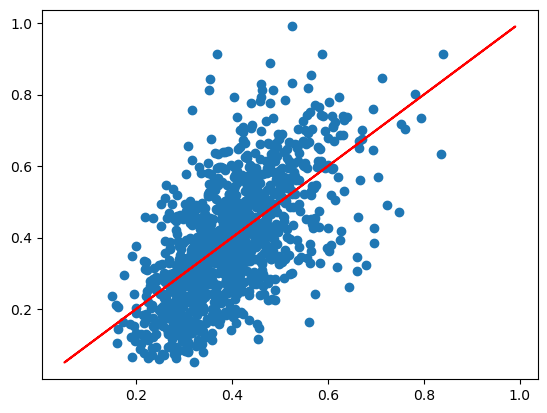

In [14]:
y_pred = better.predict(X_test)
plt.plot(y_test, y_test, color='red')
plt.scatter(y_pred, y_test)

__Автоматизация отбора признаков__

In [15]:
df.data.shape

(4450, 202)

In [16]:
from sklearn.feature_selection import SelectFromModel

sfm = SelectFromModel(RandomForestRegressor(n_estimators=15)).fit(df.data, df.target)
X_trimmed = sfm.transform(df.data)
X_trimmed.shape

(4450, 52)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X_trimmed, df.target, test_size=0.25, random_state=42)

better = LinearRegression()
better.fit(X_train, y_train)

print(bl_score)
better.score(X_test, y_test)

-1.6511340769823937


0.43672952762351525

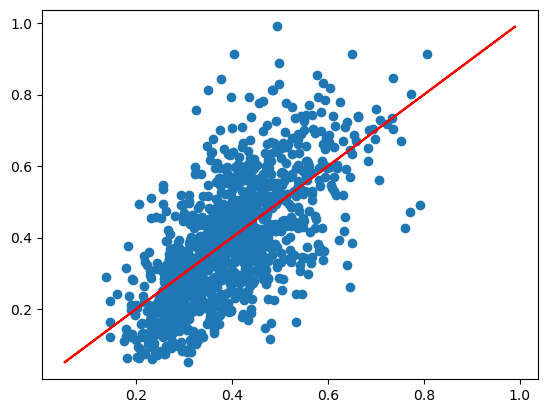

In [18]:
y_pred = better.predict(X_test)
plt.plot(y_test, y_test, color='red')
plt.scatter(y_pred, y_test)

__Устранение дисбаланса классов__

In [19]:
df = fetch_openml("balance-scale", version=1)

df.data.head()

,left-weight,left-distance,right-weight,right-distance
0,1,1,1,1
1,1,1,1,2
2,1,1,1,3
3,1,1,1,4
4,1,1,1,5


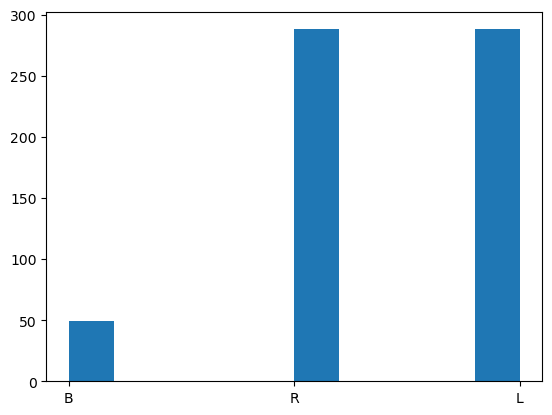

In [20]:
plt.hist(df.target);

In [21]:
X_train, X_test, y_train, y_test = train_test_split(df.data, df.target, test_size=0.25, random_state=42, stratify=df.target)

In [22]:
from sklearn.linear_model import LogisticRegression
baseline = LogisticRegression()
baseline.fit(X_train, y_train)
bl_score = baseline.score(X_test, y_test)
bl_score

0.8598726114649682

In [23]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, baseline.predict(X_test)))

              precision    recall  f1-score   support

           B       0.00      0.00      0.00        12
           L       0.87      0.92      0.89        73
           R       0.86      0.94      0.90        72

    accuracy                           0.86       157
   macro avg       0.58      0.62      0.60       157
weighted avg       0.80      0.86      0.83       157



In [24]:
print(confusion_matrix(y_test, baseline.predict(X_test)))

[[ 0  6  6]
 [ 1 67  5]
 [ 0  4 68]]


In [25]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np


class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(zip(np.unique(y_train), class_weights))
class_weights

{'B': 4.216216216216216, 'L': 0.7255813953488373, 'R': 0.7222222222222222}

In [26]:
weighted = LogisticRegression(class_weight=class_weights)
weighted.fit(X_train, y_train)
print(bl_score)
weighted.score(X_test, y_test)

0.8598726114649682


0.9235668789808917

In [27]:
print(classification_report(y_test, weighted.predict(X_test)))

              precision    recall  f1-score   support

           B       0.61      0.92      0.73        12
           L       0.97      0.92      0.94        73
           R       0.96      0.93      0.94        72

    accuracy                           0.92       157
   macro avg       0.85      0.92      0.87       157
weighted avg       0.94      0.92      0.93       157



__Oversampling__

In [28]:
y_train.value_counts()

class
R    216
L    215
B     37
Name: count, dtype: int64

In [29]:
X_train["target"] = y_train

In [30]:
oversampled = X_train[X_train.target == "B"].sample(n=216-37, replace=True, ignore_index=True)

In [31]:
import pandas as pd

oversampled = pd.concat([X_train, oversampled])
print(oversampled.shape)
oversampled.head()

(647, 5)


,left-weight,left-distance,right-weight,right-distance,target
262,3,1,3,3,R
401,4,2,1,2,L
174,2,2,5,5,R
81,1,4,2,2,B
36,1,2,3,2,R


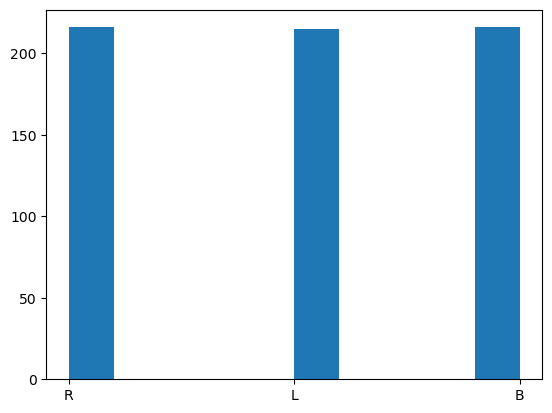

In [32]:
plt.hist(oversampled['target']);

In [33]:
y_train_OS = oversampled.target
X_train_OS = oversampled.drop(["target"], axis=1)

In [34]:
OSmodel = LogisticRegression()
OSmodel.fit(X_train_OS, y_train_OS)
print(bl_score)
OSmodel.score(X_test, y_test)

0.8598726114649682


0.9235668789808917

In [35]:
print(classification_report(y_test, OSmodel.predict(X_test)))

              precision    recall  f1-score   support

           B       0.61      0.92      0.73        12
           L       0.97      0.92      0.94        73
           R       0.96      0.93      0.94        72

    accuracy                           0.92       157
   macro avg       0.85      0.92      0.87       157
weighted avg       0.94      0.92      0.93       157



__Дискретизация целевой переменной__

In [36]:
df = fetch_openml("CPMP-2015-regression", version=1)
df.data.drop(["instance_id"], inplace=True, axis=1)
df.data = pd.get_dummies(df.data)
df.data.head()

C:\Users\242077\AppData\Local\Temp\ipykernel_15704\1011001378.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.data.drop(["instance_id"], inplace=True, axis=1)


,repetition,stacks,tiers,stack.tier.ratio,container.density,empty.stack.pct,overstowing.stack.pct,overstowing.2cont.stack.pct,group.same.min,group.same.max,...,avg.l1.top.left.lg.group,cont.empty.grt.estack,pct.bottom.pct.on.top,algorithm_astar.symmulgt.transmul,algorithm_astar.symmullt.transmul,algorithm_idastar.symmulgt.transmul,algorithm_idastar.symmullt.transmul,runstatus_memout,runstatus_ok,runstatus_timeout
0,1,16,5,0.3125,0.6,0.0625,0.6250,0.909091,0,6,...,0.509615,0.1750,0.0,True,False,False,False,False,True,False
1,1,16,5,0.3125,0.6,0.0625,0.6250,0.909091,0,6,...,0.509615,0.1750,0.0,False,True,False,False,False,True,False
2,1,16,5,0.3125,0.6,0.0625,0.6250,0.909091,0,6,...,0.509615,0.1750,0.0,False,False,True,False,False,True,False
3,1,16,5,0.3125,0.6,0.0625,0.6250,0.909091,0,6,...,0.509615,0.1750,0.0,False,False,False,True,False,False,True
4,1,16,5,0.3125,0.6,0.1875,0.5625,1.000000,0,7,...,0.663462,0.3375,0.0,True,False,False,False,True,False,False


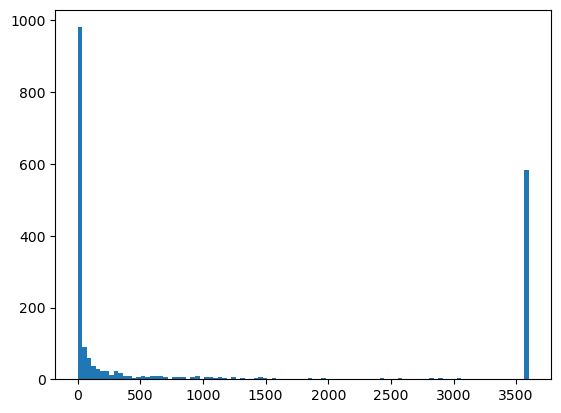

In [37]:
plt.hist(df.target, 100)
_ = plt.plot()

In [38]:
X_train, X_test, y_train, y_test = train_test_split(df.data, df.target, test_size=0.25, random_state=42)

In [39]:
from sklearn.preprocessing import KBinsDiscretizer

y_binned = KBinsDiscretizer(n_bins=5, encode="ordinal", strategy="uniform").fit_transform(pd.DataFrame(y_train))

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:248: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(


In [40]:
y_binned = KBinsDiscretizer(n_bins=5, encode="ordinal", strategy="quantile").fit_transform(pd.DataFrame(y_train))

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:322: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


# Домашняя работа

1. Исследуйте связь между количеством самых важных признаков, которые использует модель для обучения и тестовой точностью получившейся модели. Обучите несколько моделей с разным количеством наиболее важных признаков. Постройте график зависимости точности модели от количества признаков. Сделайте вывод.

In [43]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import numpy as np

In [44]:
df = fetch_openml("mtp", version=1)

In [45]:
X_train, X_test, y_train, y_test = train_test_split(df.data, df.target, test_size=0.25, random_state=42)

In [46]:
rf = RandomForestRegressor(n_estimators=15).fit(X_train, y_train)

In [47]:
sort = rf.feature_importances_.argsort()

In [48]:
scores = []
features_count = list(range(5, 101, 5))

In [49]:
for k in features_count:
    selected = df.data[df.data.columns[sort][-k:]]
    
    X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(selected, df.target, test_size=0.25, random_state=42)
    
    model = LinearRegression()
    model.fit(X_train_k, y_train_k)
    
    scores.append(model.score(X_test_k, y_test_k))

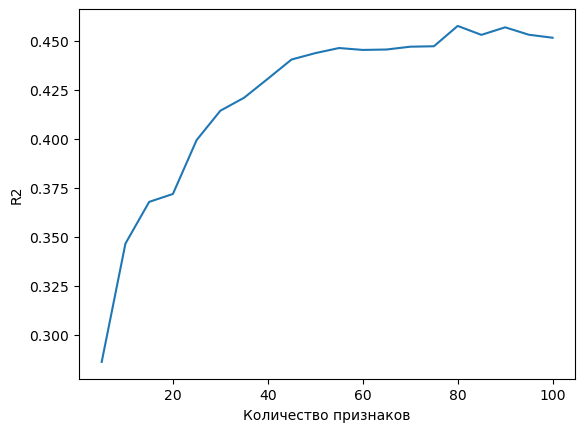

In [50]:
plt.plot(features_count, scores)
plt.xlabel("Количество признаков")
plt.ylabel("R2")
plt.show()

2. Используйте другие методы отбора признаков:
Исключение низкодисперсных признаков;
Исключение по парным стаистическим критериям (хи-квадрат, тест Фишера, коэффициент корреляции, информационный критерий);
Рекурсивное исключение признаков;
Последовательное включение признаков;
Исключение по L1-норме (гребневой регрессии).

i)

In [52]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
X_var = selector.fit_transform(df.data)

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X_var, df.target, test_size=0.25, random_state=42)

In [54]:
model = LinearRegression().fit(X_train, y_train)
print(model.score(X_test, y_test))

-1.2929634081226302


ii)

In [57]:
import pandas as pd
corr = df.data.copy()
corr["target"] = df.target

In [58]:
correlations = corr.corr()["target"].abs().sort_values()

In [59]:
selected_features = correlations.index[-20:-1]


In [60]:
X_corr = df.data[selected_features]

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X_corr, df.target, test_size=0.25, random_state=42)

In [62]:
model = LinearRegression().fit(X_train, y_train)
print(model.score(X_test, y_test))

0.34139107621565445


iii)

In [63]:
from sklearn.feature_selection import RFE

model = LinearRegression()
rfe = RFE(model, n_features_to_select=20)

In [64]:
X_rfe = rfe.fit_transform(df.data, df.target)

In [65]:
X_train, X_test, y_train, y_test = train_test_split(X_rfe, df.target, test_size=0.25, random_state=42)

In [66]:
model.fit(X_train, y_train)
print(model.score(X_test, y_test))

0.20622999727713043


iv)

In [67]:
from sklearn.feature_selection import SequentialFeatureSelector

model = LinearRegression()

In [68]:
sfs = SequentialFeatureSelector(model, n_features_to_select=20, direction="forward")

In [69]:
X_sfs = sfs.fit_transform(df.data, df.target)

In [70]:
X_train, X_test, y_train, y_test = train_test_split(X_sfs, df.target, test_size=0.25, random_state=42)


In [71]:
model.fit(X_train, y_train)
print(model.score(X_test, y_test))

0.39873704636567475


v)

In [72]:
from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel

lasso = Lasso(alpha=0.01).fit(df.data, df.target)

In [73]:
sfm = SelectFromModel(lasso, prefit=True)
X_l1 = sfm.transform(df.data)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


In [74]:
X_train, X_test, y_train, y_test = train_test_split(X_l1, df.target, test_size=0.25, random_state=42)

In [75]:
model = LinearRegression().fit(X_train, y_train)
print(model.score(X_test, y_test))

0.17402696264905915


3. Изучите возможности библиотеки imbalanced-learn. Примените на данном примере возможности данной библиотеки для оверсемплинга и андерсемплинга выборки.

In [76]:
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

In [77]:
df = fetch_openml("balance-scale", version=1)

In [78]:
X_train, X_test, y_train, y_test = train_test_split(df.data, df.target, test_size=0.25, random_state=42, stratify=df.target)

oversampling

In [79]:
ros = RandomOverSampler()
X_ros, y_ros = ros.fit_resample(X_train, y_train)

In [80]:
model = LogisticRegression().fit(X_ros, y_ros)
print(model.score(X_test, y_test))

0.9235668789808917


undersampling

In [83]:
rus = RandomUnderSampler()
X_rus, y_rus = rus.fit_resample(X_train, y_train)

In [84]:
model = LogisticRegression().fit(X_rus, y_rus)
print(model.score(X_test, y_test))

0.8598726114649682


4. Исследуйте влияние дискретизации целевой переменной на качество модели. Используйте уже продемострированный подход - построение базовой модели (baseline) и сравнение модели после обработки данных с базовой. Проверьте разное количество категорий, а также разные стратегии группировки. Сделайте выводы. Обратите внимание, что после биннинга целевой переменной она стала категориальной. А значит, задача превратилась в задачу классификации.
Контрольные вопросы

In [85]:
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import accuracy_score

In [86]:
df = fetch_openml("CPMP-2015-regression", version=1)

In [87]:
df.data.drop(["instance_id"], axis=1, inplace=True)
df.data = pd.get_dummies(df.data)

C:\Users\242077\AppData\Local\Temp\ipykernel_15704\2126879684.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.data.drop(["instance_id"], axis=1, inplace=True)


In [88]:
X_train, X_test, y_train, y_test = train_test_split(df.data, df.target, test_size=0.25, random_state=42)

In [89]:
model = LinearRegression().fit(X_train, y_train)
print(model.score(X_test, y_test))

0.891977926998725


In [90]:
kbd = KBinsDiscretizer(n_bins=5, encode="ordinal", strategy="quantile")

In [91]:
y_train_bin = kbd.fit_transform(pd.DataFrame(y_train)).ravel()
y_test_bin = kbd.transform(pd.DataFrame(y_test)).ravel()

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:322: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


In [92]:
clf = LogisticRegression()
clf.fit(X_train, y_train_bin)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [93]:
pred = clf.predict(X_test)
print(accuracy_score(y_test_bin, pred))

0.6413662239089184
